[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Apr 28 09:34:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

## Install YOLO11 via Ultralytics

In [2]:
# Fix YOLOv11 + Ray Tune callback error in Colab / Jupyter

# Step 1: uninstall incompatible ray version
!pip uninstall -y ray

# Step 2: install compatible ray version
!pip install ray==2.9.3

# Step 3: reinstall ultralytics (optional but recommended)
!pip install -U ultralytics

# Step 4: restart runtime after install
# import os
# os.kill(os.getpid(), 9)

Found existing installation: ray 2.54.0
Uninstalling ray-2.54.0:
  Successfully uninstalled ray-2.54.0
ERROR: Could not find a version that satisfies the requirement ray==2.9.3 (from versions: 2.31.0, 2.32.0rc0, 2.32.0, 2.33.0, 2.34.0, 2.35.0, 2.36.0, 2.36.1, 2.37.0, 2.38.0, 2.39.0, 2.40.0, 2.41.0, 2.42.0, 2.42.1, 2.43.0, 2.44.0, 2.44.1, 2.45.0, 2.46.0, 2.47.0, 2.47.1, 2.48.0, 2.49.0, 2.49.1, 2.49.2, 2.50.0, 2.50.1, 2.51.0, 2.51.1, 2.51.2, 2.52.0, 2.52.1, 2.53.0, 2.54.0, 2.54.1, 2.55.0, 2.55.1)
ERROR: No matching distribution found for ray==2.9.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00a 0:00:01


## Inference with model pre-trained on COCO dataset

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [4]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /kaggle/working/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 52.2ms
Speed: 8.7ms preprocess, 52.2ms inference, 36.4ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

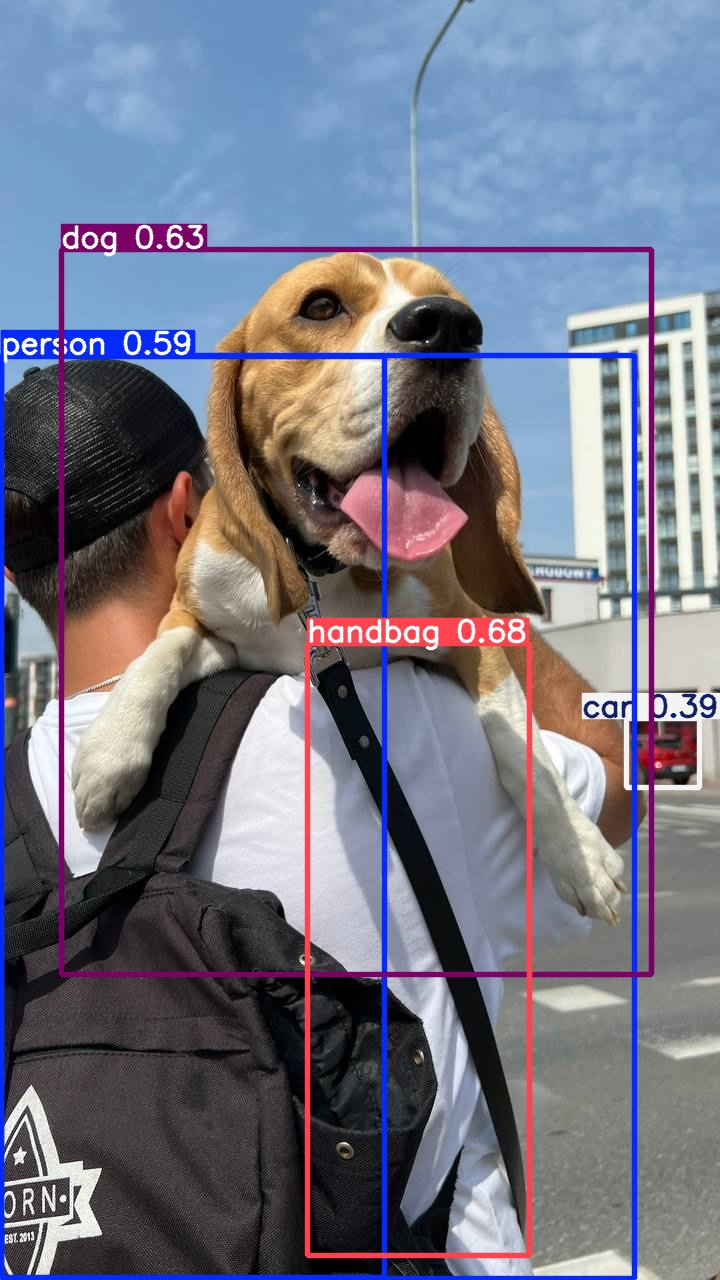

In [5]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [6]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 54.4ms
Speed: 3.4ms preprocess, 54.4ms inference, 21.9ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [7]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4341e+02, 5.2919e+02, 1.2558e+03],
        [6.1400e+01, 2.4994e+02, 6.5165e+02, 9.7412e+02],
        [1.7803e+00, 3.5551e+02, 6.3404e+02, 1.2788e+03],
        [1.1933e+00, 3.5620e+02, 3.8455e+02, 1.2776e+03],
        [6.2615e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [8]:
result.boxes.conf

tensor([0.6832, 0.6284, 0.5941, 0.3923, 0.3875], device='cuda:0')

In [9]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [10]:
# import supervision as sv

# detections = sv.Detections.from_ultralytics(result)

In [11]:
# box_annotator = sv.BoxAnnotator()
# label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

# annotated_image = image.copy()
# annotated_image = box_annotator.annotate(annotated_image, detections=detections)
# annotated_image = label_annotator.annotate(annotated_image, detections=detections)

# sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [12]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EHOn7R5Jmi11PxeMpSMH")
project = rf.workspace("university-f1igv").project("fer2025")
version = project.version(8)
dataset = version.download("yolov11")

/kaggle/working/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.0 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.2


Extracting Dataset Version Zip to FER2025-8 in yolov11:: 100%|██████████| 14784/14784 [00:01<00:00, 9714.48it/s] 


## Custom Training

In [13]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11m.pt data={dataset.location}/data.yaml epochs=50 imgsz=800 plots=True

/kaggle/working
Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/FER2025-8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [14]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch12960.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch12961.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch12962.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


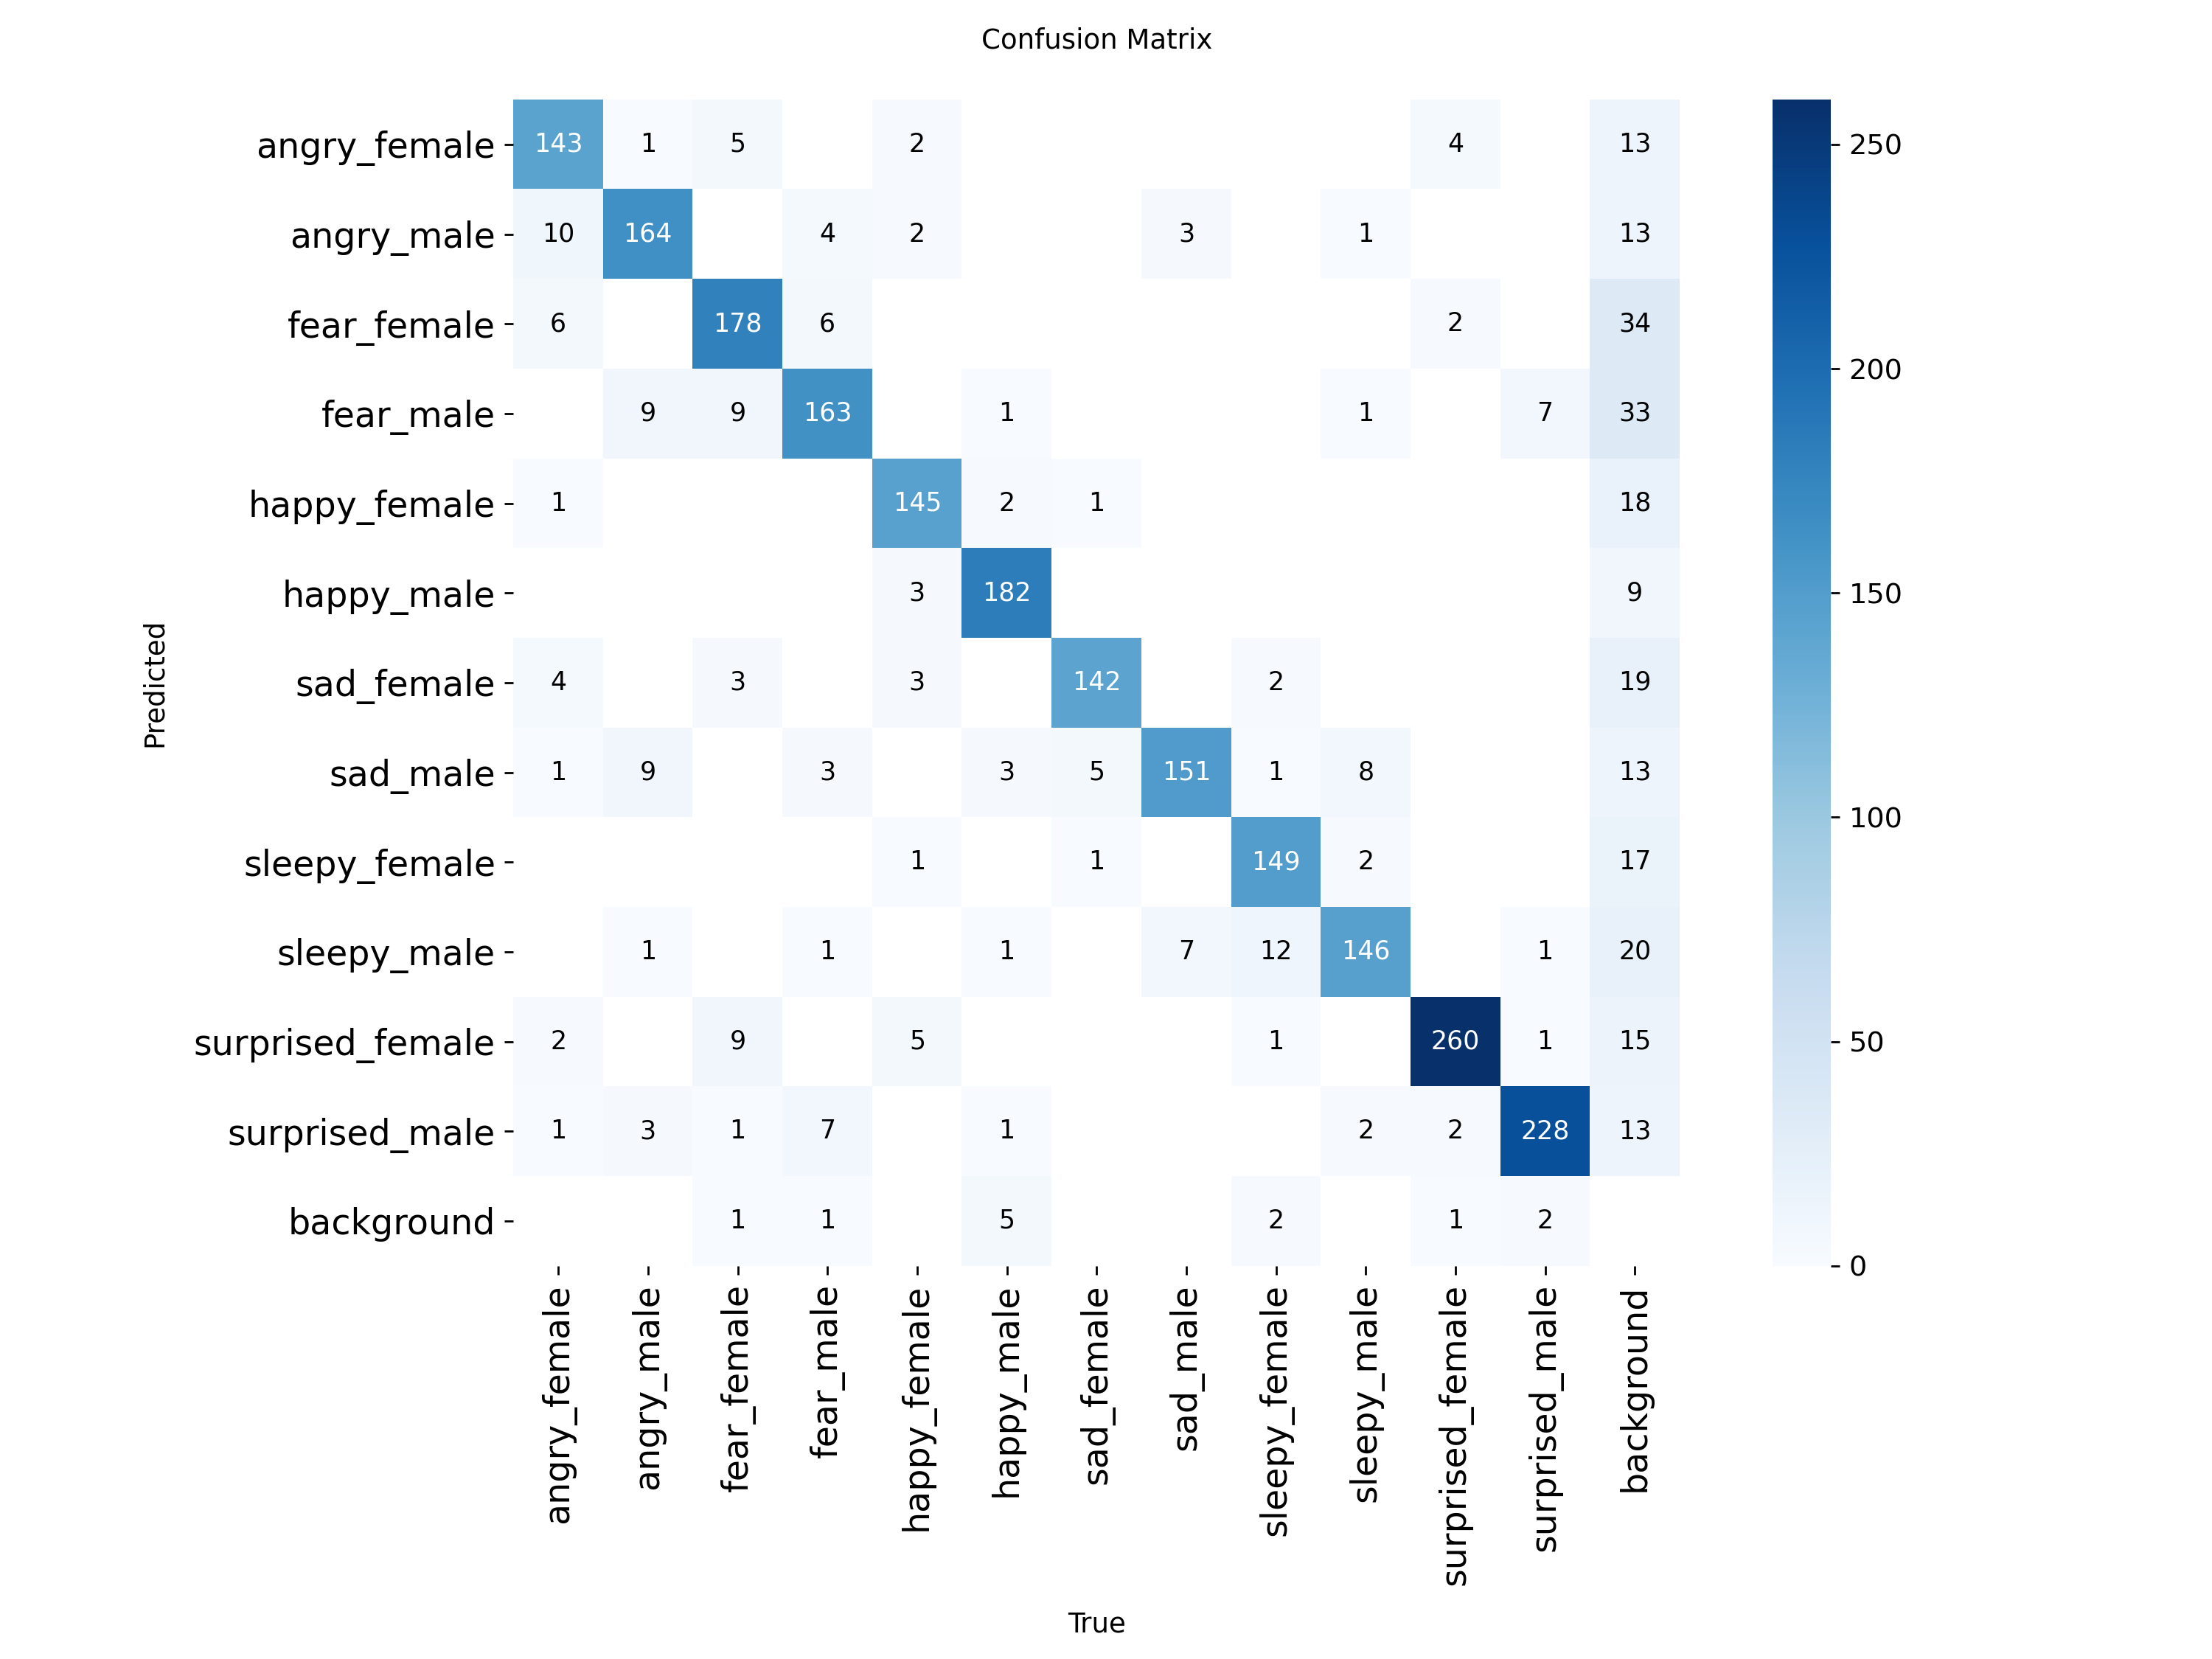

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

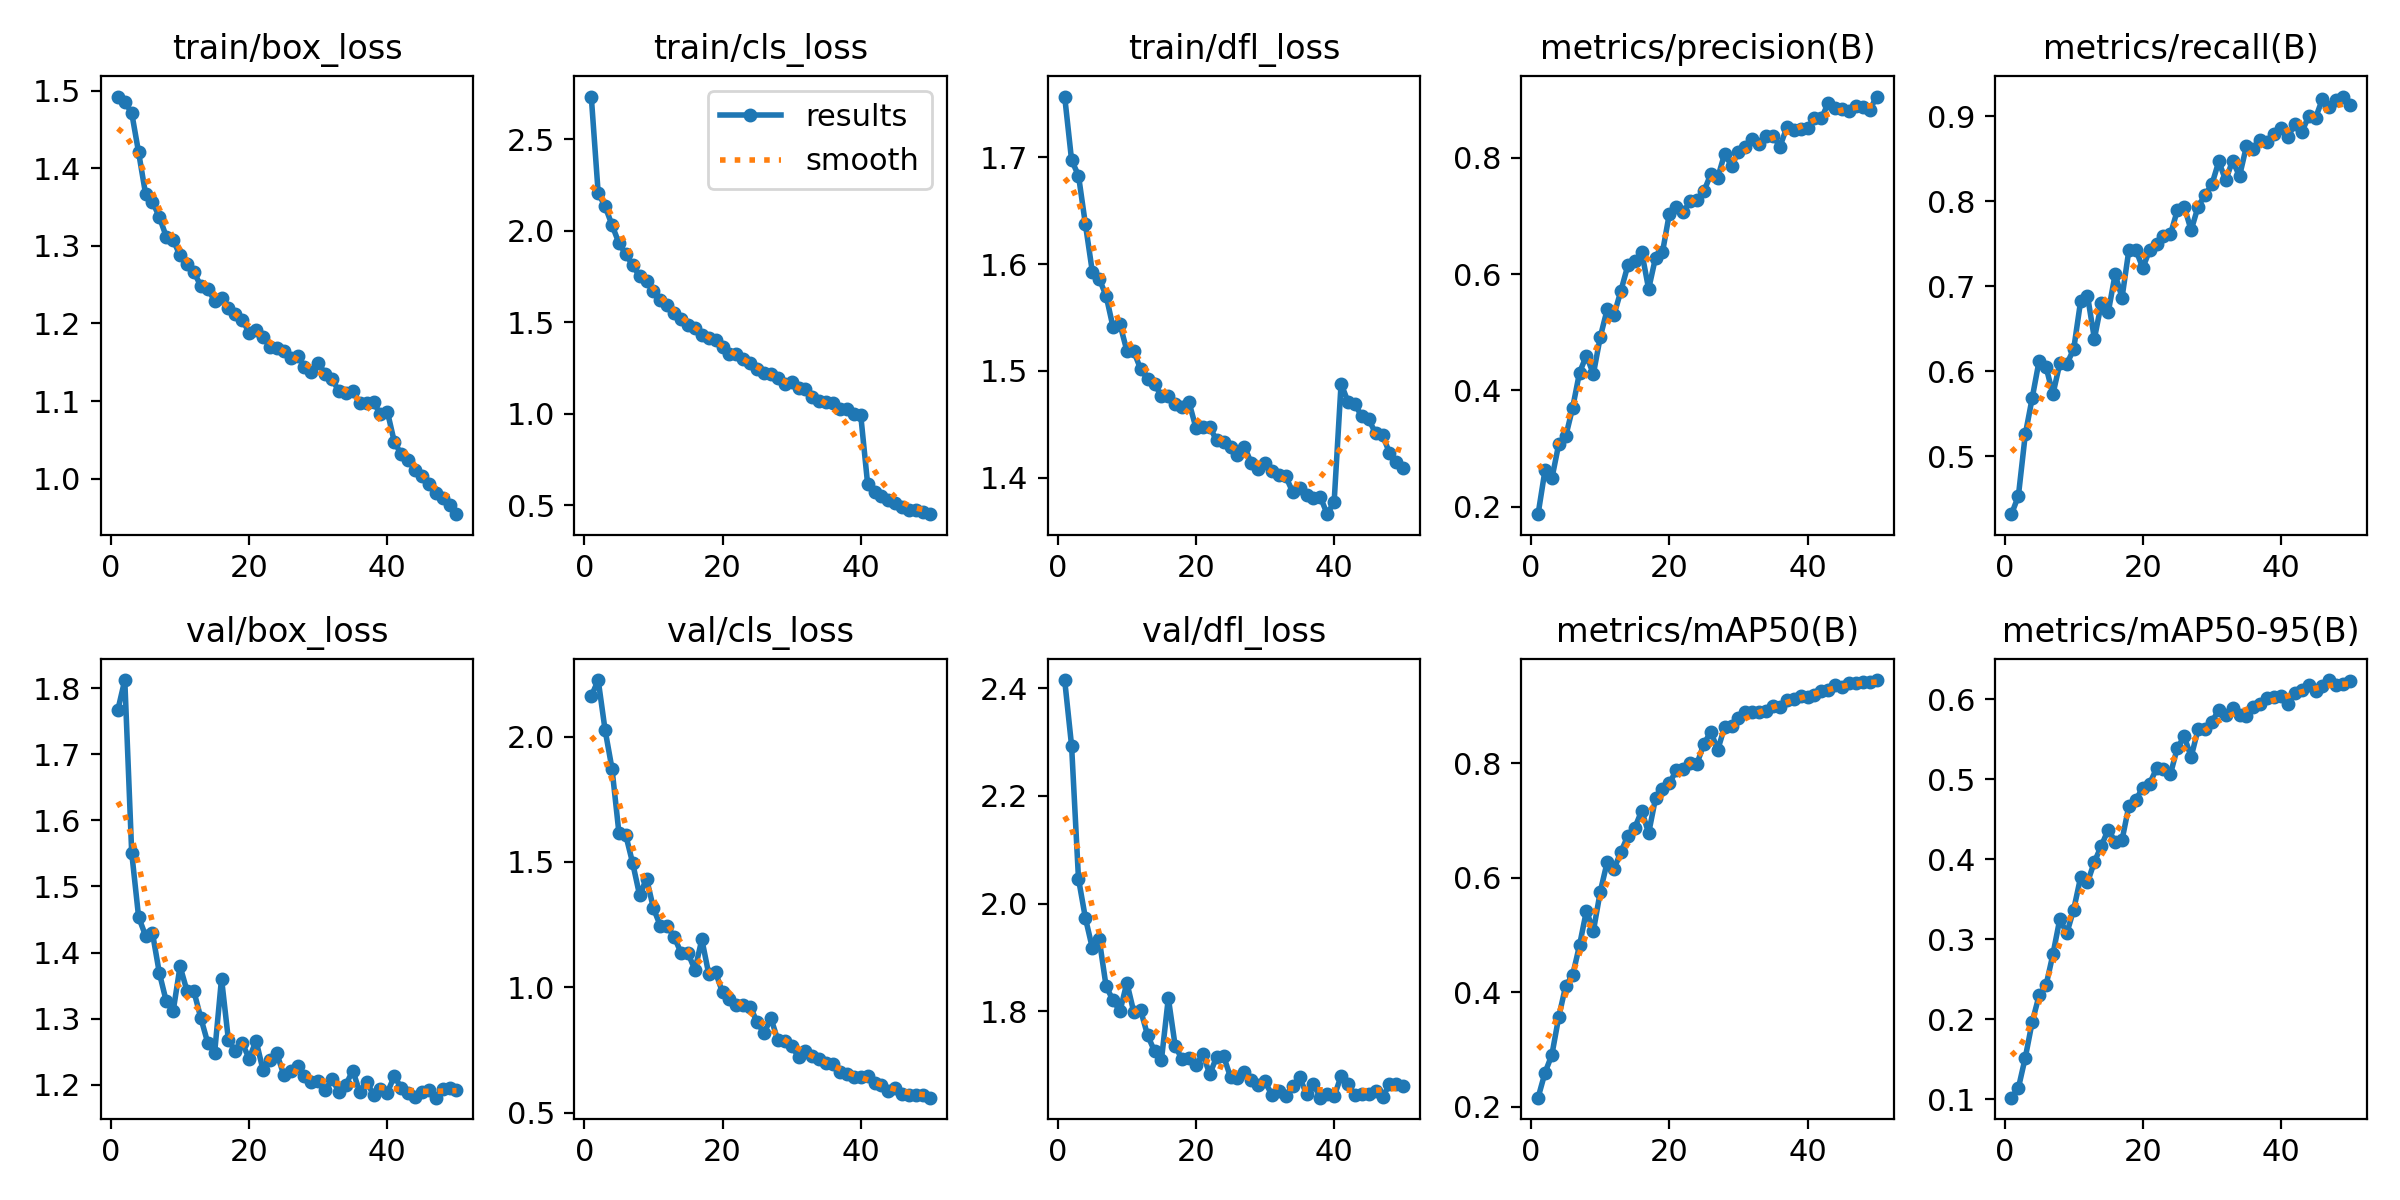

In [16]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

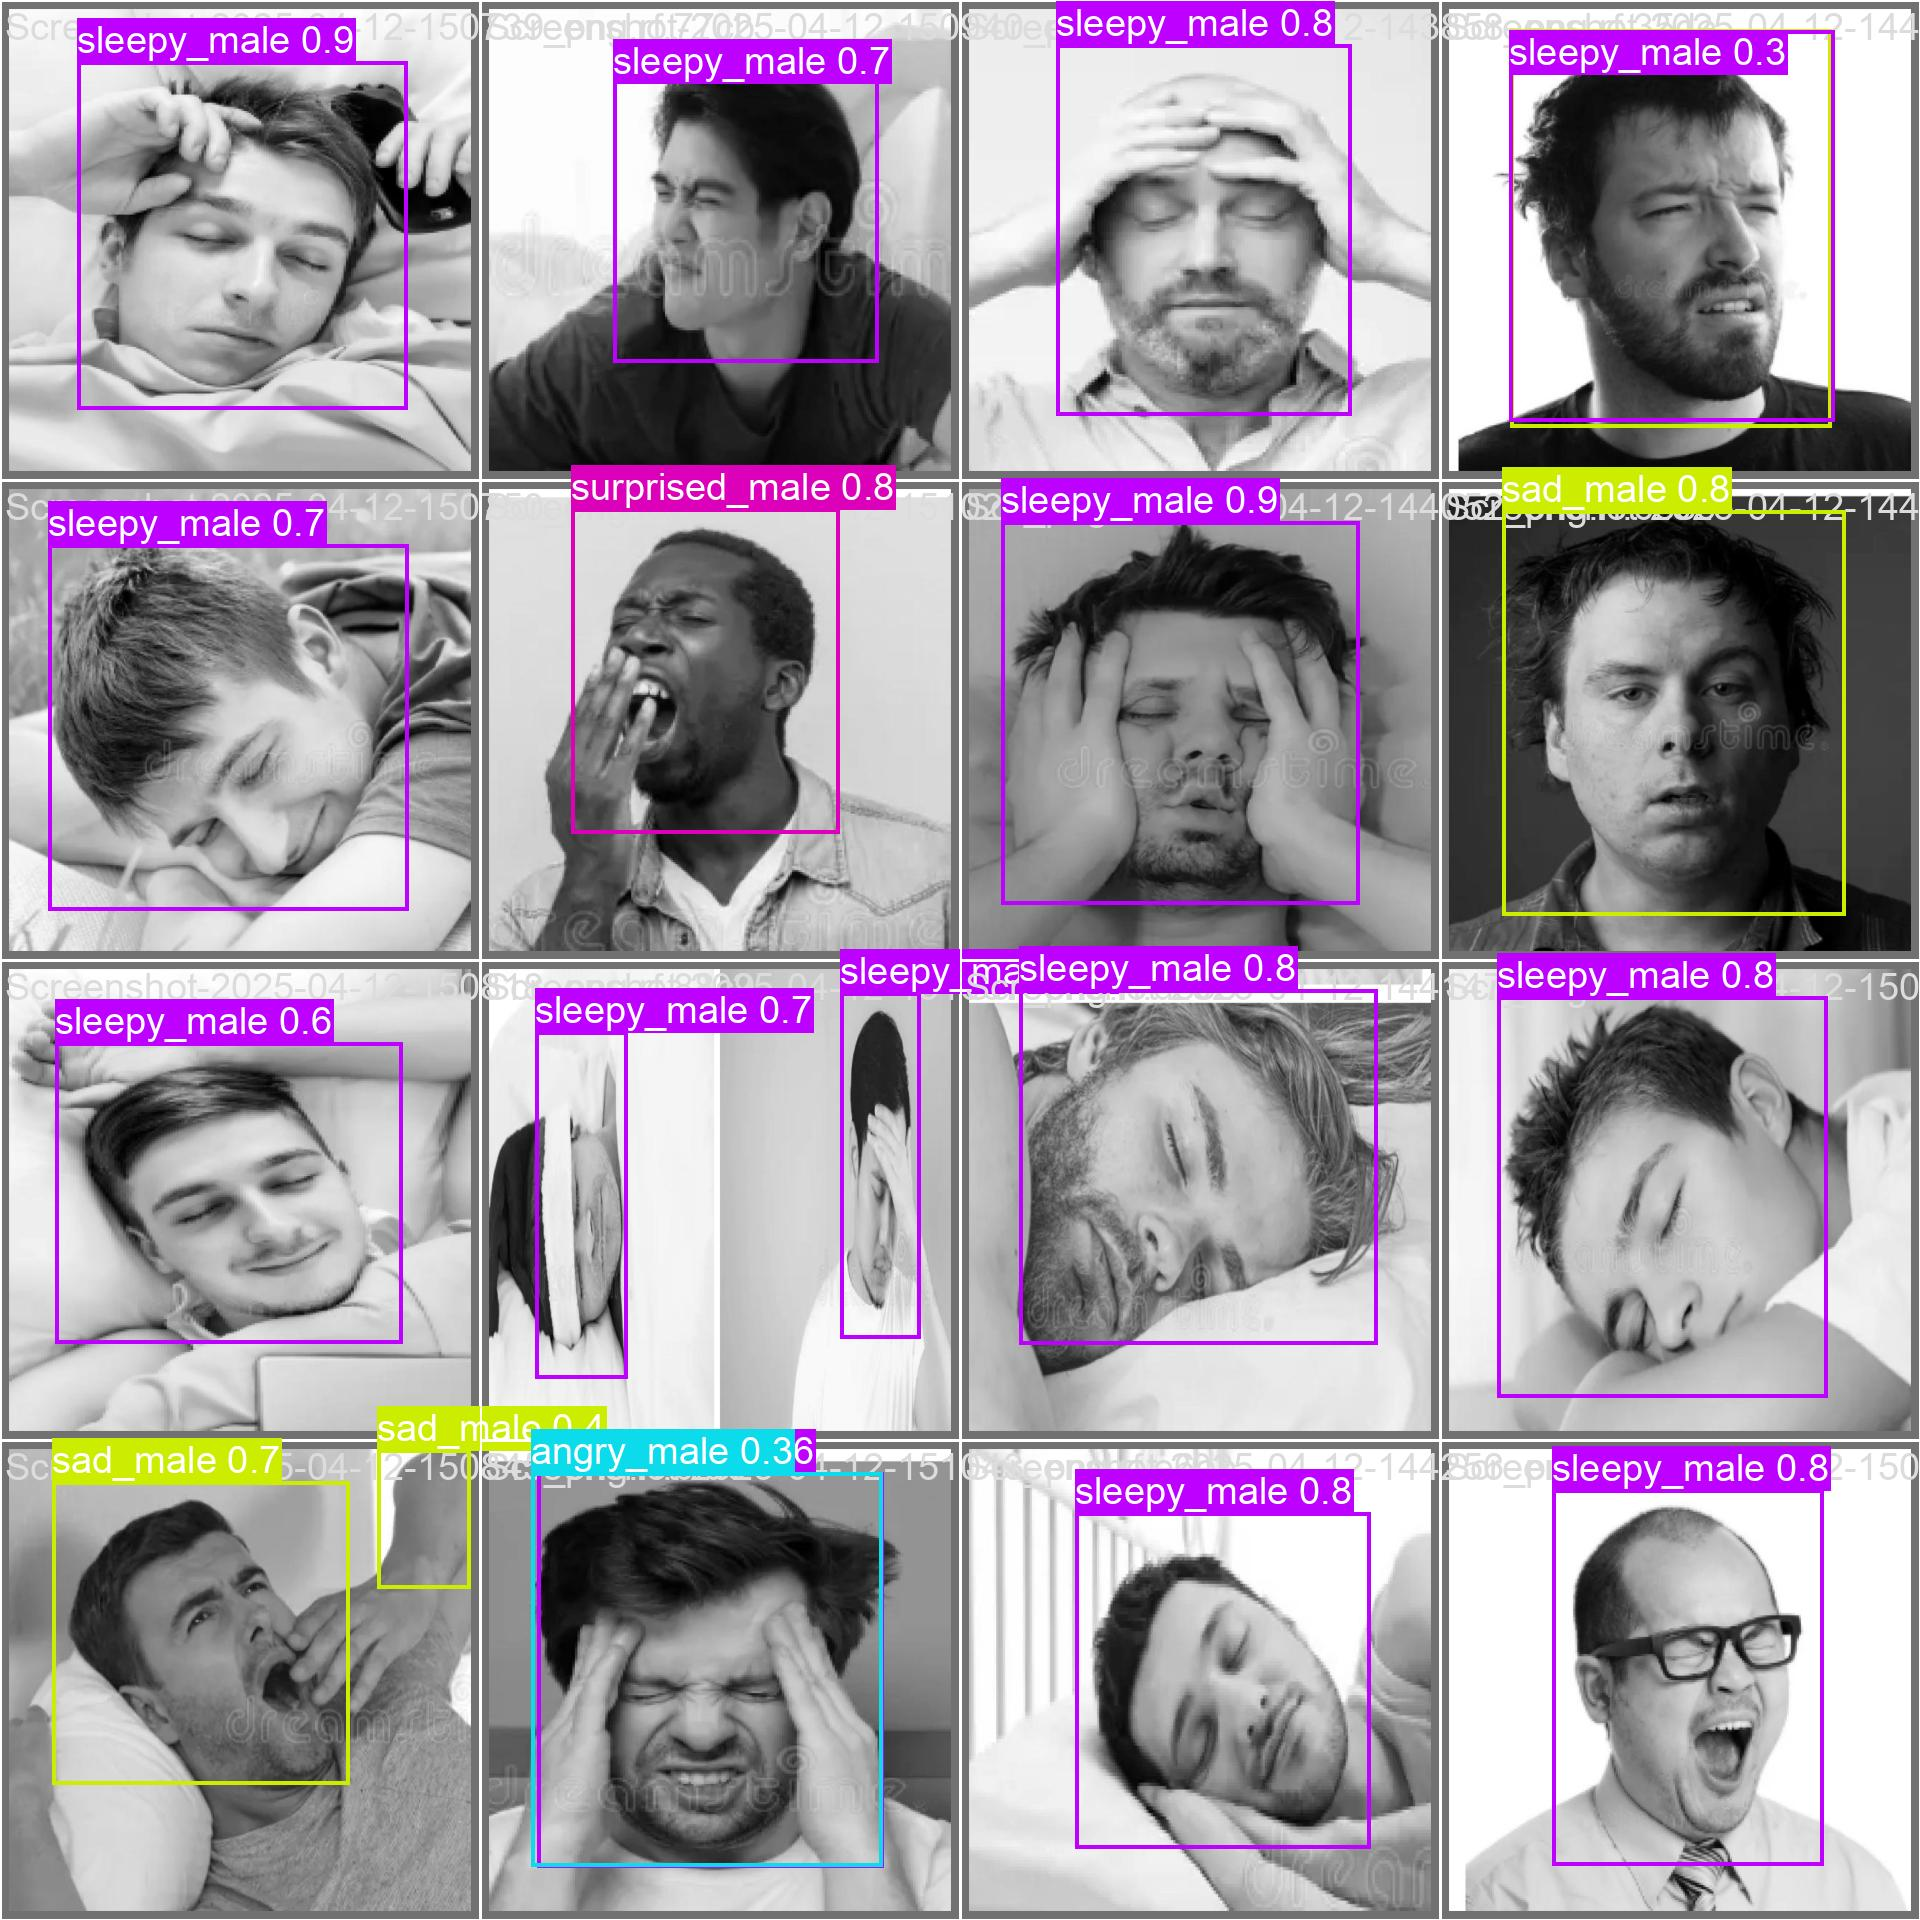

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [18]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,039,284 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1265.3±285.5 MB/s, size: 36.8 KB)
val: Scanning /kaggle/working/datasets/FER2025-8/valid/labels.cache... 1478 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1478/1478 326.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 93/93 1.4it/s 1:090.7sss
                   all       1478       2247      0.889      0.911      0.941      0.625
          angry_female        120        168      0.913       0.87      0.956       0.63
            angry_male        151        187      0.886      0.872      0.942      0.653
           fear_female        147        206      0.859      0.854      0.895      0.538
             fear_male        143        185      0.804      0.864      0.873      0.506
          happy_

## Inference with custom model

In [19]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.42 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,039,284 parameters, 0 gradients, 67.7 GFLOPs

image 1/737 /kaggle/working/datasets/FER2025-8/test/images/Screenshot-2025-03-27-194913_png.rf.5a00d7577541a62d0e34f86c09220c01.jpg: 800x800 1 fear_female, 1 fear_male, 49.9ms
image 2/737 /kaggle/working/datasets/FER2025-8/test/images/Screenshot-2025-03-27-194940_bright_png.rf.f40d5be04f45883332d51cc50e255c84.jpg: 800x800 2 fear_males, 48.5ms
image 3/737 /kaggle/working/datasets/FER2025-8/test/images/Screenshot-2025-03-27-195005_contrast_png.rf.2ef3b47eeeefd883daf3051912f3dea8.jpg: 800x800 1 fear_male, 45.6ms
image 4/737 /kaggle/working/datasets/FER2025-8/test/images/Screenshot-2025-03-27-195222_png.rf.636c457ca3fc0066da5f5569d8089b7a.jpg: 800x800 20 fear_females, 4 fear_males, 1 happy_female, 45.3ms
image 5/737 /kaggle/working/datasets/FER2025-8/test/images/Screenshot-2025-03-27-195236_bright_png.rf.165f983f19c3444db6f

**NOTE:** Let's take a look at few results.

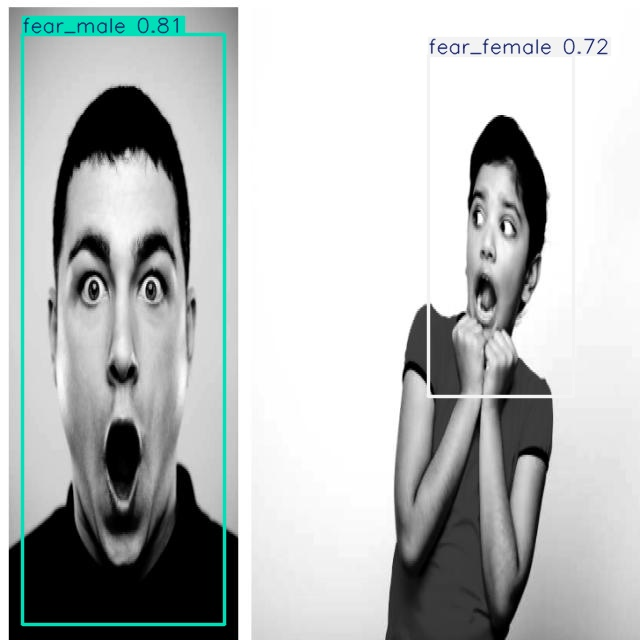

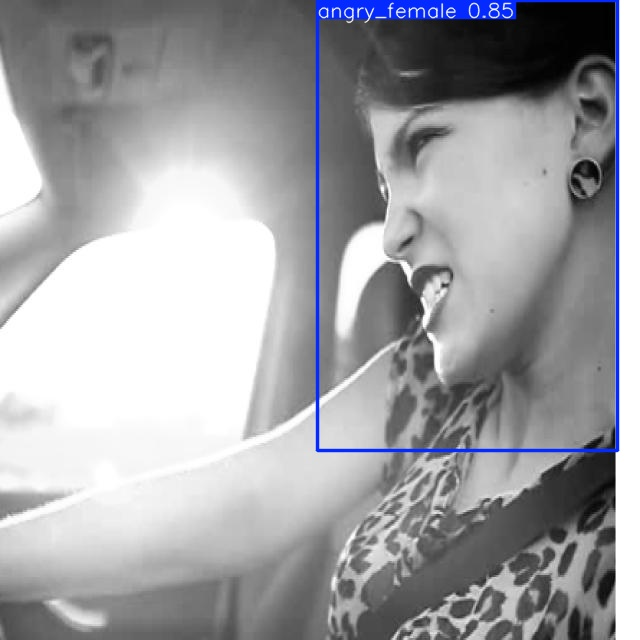

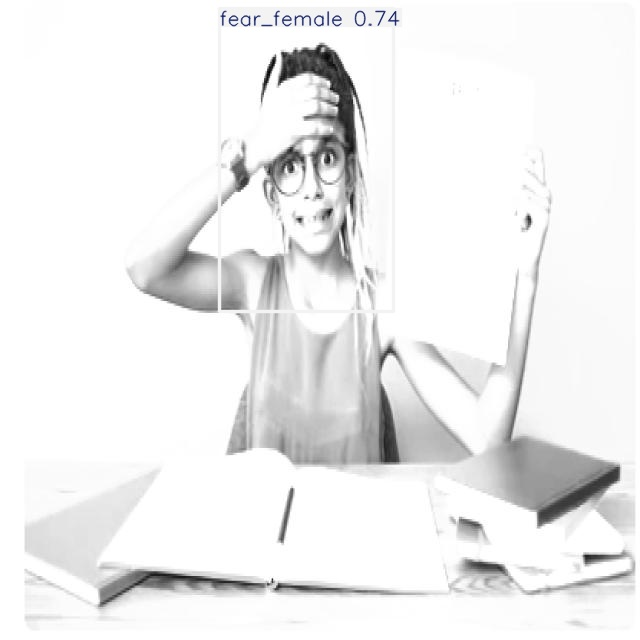

In [20]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [21]:
# Zip the runs folder and create a download link
import os
from IPython.display import FileLink

# Zip folder
os.system("zip -r runs.zip /kaggle/working/runs")

# Show download link
FileLink("runs.zip")

  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/train/ (stored 0%)
  adding: kaggle/working/runs/detect/train/train_batch12962.jpg (deflated 14%)
  adding: kaggle/working/runs/detect/train/weights/ (stored 0%)
  adding: kaggle/working/runs/detect/train/weights/last.pt (deflated 8%)
  adding: kaggle/working/runs/detect/train/weights/best.pt (deflated 8%)
  adding: kaggle/working/runs/detect/train/confusion_matrix.png (deflated 16%)
  adding: kaggle/working/runs/detect/train/val_batch2_pred.jpg (deflated 13%)
  adding: kaggle/working/runs/detect/train/train_batch12961.jpg (deflated 15%)
  adding: kaggle/working/runs/detect/train/val_batch2_labels.jpg (deflated 15%)
  adding: kaggle/working/runs/detect/train/results.png (deflated 7%)
  adding: kaggle/working/runs/detect/train/confusion_matrix_normalized.png (deflated 14%)
  adding: kaggle/working/runs/detect/train/val_batch1_pred.jpg (deflated 18%)
  adding:

/kaggle/working/runs.zip